# Projet COVID 19 : Modelisation Random Forest - 4 classes - Balanced - 3ème itération

In [1]:
%whos

Interactive namespace is empty.


## Conditions de modélisation

## Environnement de travail

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    average_precision_score
)

from sklearn.inspection import permutation_importance
import joblib

In [3]:
# Répertoire du notebook
NOTEBOOK_DIR = Path.cwd()

# Racine du projet (Liora_Covid)
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

# Dossier des CSV
DATA_DIR = PROJECT_ROOT / "csv"

print("Notebook :", NOTEBOOK_DIR)
print("Projet   :", PROJECT_ROOT)
print("CSV      :", DATA_DIR)

Notebook : /home/cyril/liora/Liora_Covid/models/random_forest
Projet   : /home/cyril/liora/Liora_Covid
CSV      : /home/cyril/liora/Liora_Covid/csv


In [4]:
# Chargement des données
train = pd.read_csv(DATA_DIR / "train_features.csv")
validation = pd.read_csv(DATA_DIR / "validation_features.csv")
test = pd.read_csv(DATA_DIR / "test_features.csv")

print(f"\nTrain      : {train.shape}")
print(f"Validation : {validation.shape}")
print(f"Test       : {test.shape}")


Train      : (16668, 6)
Validation : (2083, 6)
Test       : (2084, 6)


## Définition de la cible et des features

In [5]:
target = "classe"

features = [
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

target = "classe"

X_train = train[features]
y_train = train[target]

X_val = validation[features]
y_val = validation[target]

X_test = test[features]
y_test = test[target]

## Vérification des classes

In [6]:
print("Distribution train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution validation :")
print(y_val.value_counts(normalize=True))

print("\nDistribution test :")
print(y_test.value_counts(normalize=True))

Distribution train :
classe
Normal             0.486501
Lung_Opacity       0.287437
COVID              0.161867
Viral Pneumonia    0.064195
Name: proportion, dtype: float64

Distribution validation :
classe
Normal             0.486318
Lung_Opacity       0.287086
COVID              0.162266
Viral Pneumonia    0.064330
Name: proportion, dtype: float64

Distribution test :
classe
Normal             0.486564
Lung_Opacity       0.287428
COVID              0.161708
Viral Pneumonia    0.064299
Name: proportion, dtype: float64


## Pipeline Random Forest

In [7]:
rf_pipe = Pipeline([
    ("model", RandomForestClassifier(
        random_state=0,
        class_weight="balanced",
        n_jobs=-1
    ))
])

## Grille des Hyperparamètres

In [8]:
param_grid_v3 = {
    "model__n_estimators": [200],
    "model__max_depth": [15, 20, 25],
    "model__min_samples_split": [10, 15, 20],
    "model__min_samples_leaf": [2, 3, 4, 5],
    "model__max_features": ["sqrt"]
}

## Cross-validation stratifiée + GridSearch

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

grid_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_v3,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


/home/cyril/.conda/envs/projetLioraTensorFlow/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/cyril/.conda/envs/projetLioraTensorFlow/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/cyril/.conda/envs/projetLioraTensorFlow/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/hom

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [15, 20, ...], 'model__max_features': ['sqrt'], 'model__min_samples_leaf': [2, 3, ...], 'model__min_samples_split': [10, 15, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In t

In [10]:
# Meilleurs paramètres

print("Meilleurs paramètres :")
print(grid_rf.best_params_)

print("\nMeilleur score F1 moyen en cross-validation :")
print(grid_rf.best_score_)

Meilleurs paramètres :
{'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 15, 'model__n_estimators': 200}

Meilleur score F1 moyen en cross-validation :
0.6109250536808872


Les meilleurs paramètres sont dans les intervals de la gridsearch. Cette optimisation est retenue.

In [11]:
# Résultats de la GridSearch

results = pd.DataFrame(grid_rf.cv_results_)
results = results.sort_values("rank_test_score")

results[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "params"
]].head(10)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
1,1,0.610925,0.004121,0.799306,0.002642,"{'model__max_depth': 15, 'model__max_features'..."
5,2,0.610089,0.004681,0.775638,0.003627,"{'model__max_depth': 15, 'model__max_features'..."
8,3,0.609216,0.004178,0.771203,0.002547,"{'model__max_depth': 15, 'model__max_features'..."
2,4,0.609081,0.002007,0.779275,0.003246,"{'model__max_depth': 15, 'model__max_features'..."
0,5,0.608987,0.004883,0.825672,0.001975,"{'model__max_depth': 15, 'model__max_features'..."
9,6,0.608807,0.003513,0.801486,0.002016,"{'model__max_depth': 15, 'model__max_features'..."
13,7,0.608664,0.003712,0.840498,0.003253,"{'model__max_depth': 20, 'model__max_features'..."
11,8,0.608527,0.004461,0.767749,0.002917,"{'model__max_depth': 15, 'model__max_features'..."
14,9,0.608497,0.004589,0.813763,0.003290,"{'model__max_depth': 20, 'model__max_features'..."
3,10,0.608487,0.005608,0.818183,0.002319,"{'model__max_depth': 15, 'model__max_features'..."


Les meilleurs modèles obtiennent un F1 macro moyen d'environ 0,48 en validation croisée. L'écart entre les scores d'entraînement et de validation indique un surapprentissage modéré, malgré une bonne stabilité des résultats entre les plis de validation.

## Évaluation sur validation

### Classification report

In [12]:
best_rf = grid_rf.best_estimator_

y_val_pred = best_rf.predict(X_val)
y_val_proba = best_rf.predict_proba(X_val)

print("Évaluation sur le jeu de validation")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Balanced accuracy :", balanced_accuracy_score(y_val, y_val_pred))
print("Precision macro :", precision_score(y_val, y_val_pred, average="macro"))
print("Recall macro :", recall_score(y_val, y_val_pred, average="macro"))
print("F1-score macro :", f1_score(y_val, y_val_pred, average="macro"))
print("F1-score weighted :", f1_score(y_val, y_val_pred, average="weighted"))

print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred))

Évaluation sur le jeu de validation
Accuracy : 0.6168987037926068
Balanced accuracy : 0.6237627247375341
Precision macro : 0.599918924956582
Recall macro : 0.6237627247375341
F1-score macro : 0.6109204932444632
F1-score weighted : 0.6129084398027239

Rapport de classification :
                 precision    recall  f1-score   support

          COVID       0.25      0.23      0.24       338
   Lung_Opacity       0.57      0.57      0.57       598
         Normal       0.72      0.73      0.72      1013
Viral Pneumonia       0.86      0.97      0.91       134

       accuracy                           0.62      2083
      macro avg       0.60      0.62      0.61      2083
   weighted avg       0.61      0.62      0.61      2083



In [ ]:
# sauvegarde du modèle
import joblib

joblib.dump(grid_rf.best_estimator_, "random_forest.joblib")

['randomforest.joblib']

### Matrice de confusion

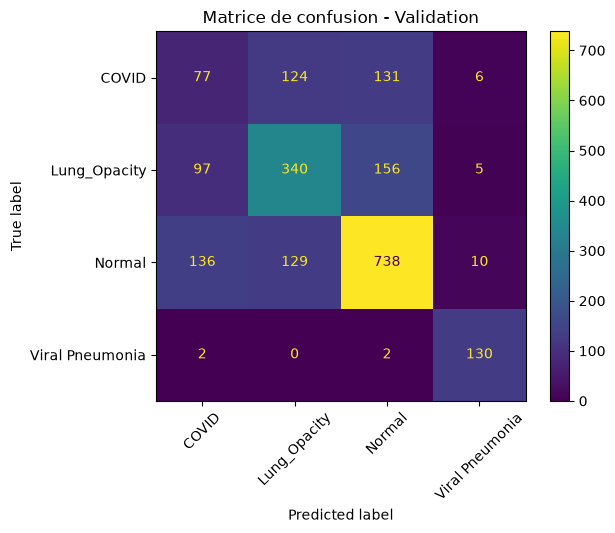

In [16]:
cm = confusion_matrix(y_val, y_val_pred)
class_names = best_rf.named_steps["model"].classes_

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion - Validation")
plt.show()

Le modèle reconnaît correctement la classe Normal (712 cas), mais présente de nombreuses confusions entre COVID, Lung_Opacity et Normal. La classe Viral Pneumonia est également difficile à identifier, avec près de la moitié des cas mal classés. Ces résultats montrent une séparation limitée entre les quatre classes.

### Features importance

In [17]:
rf_model = best_rf.named_steps["model"]

importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
0,lum_interieur_masque,0.545836
3,variance_laplacien,0.250822
2,surface_masque,0.124446
1,lum_exterieur_masque,0.078896


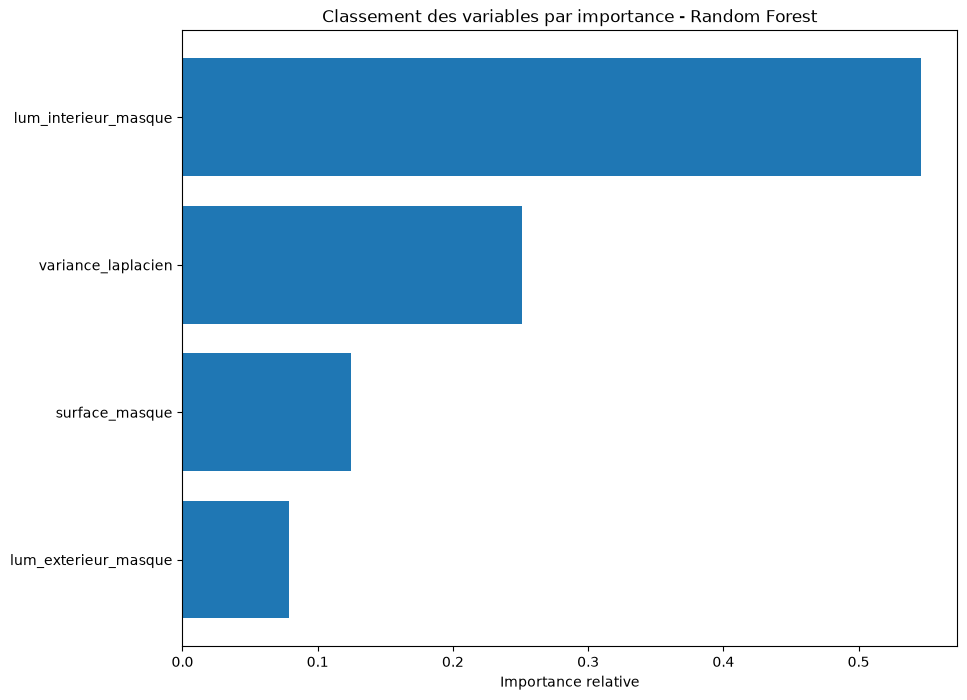

In [18]:
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df["feature"][::-1],
    feature_importance_df["importance"][::-1]
)
plt.xlabel("Importance relative")
plt.title("Classement des variables par importance - Random Forest")
plt.show()

La variable lum_interieur_masque est la plus importante pour la classification, suivie de variance_laplacien. Les variables surface_masque et lum_exterieur_masque contribuent également au modèle, mais avec un impact plus limité.

### Permutation importance

In [19]:
perm_importance = permutation_importance(
    best_rf,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=10,
    random_state=0,
    n_jobs=-1
)

In [20]:
perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

perm_df = perm_df.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

perm_df.head(20)

,feature,importance_mean,importance_std
0,lum_interieur_masque,0.246847,0.010794
1,variance_laplacien,0.155266,0.006024
2,surface_masque,0.076680,0.007896
3,lum_exterieur_masque,0.003885,0.004276


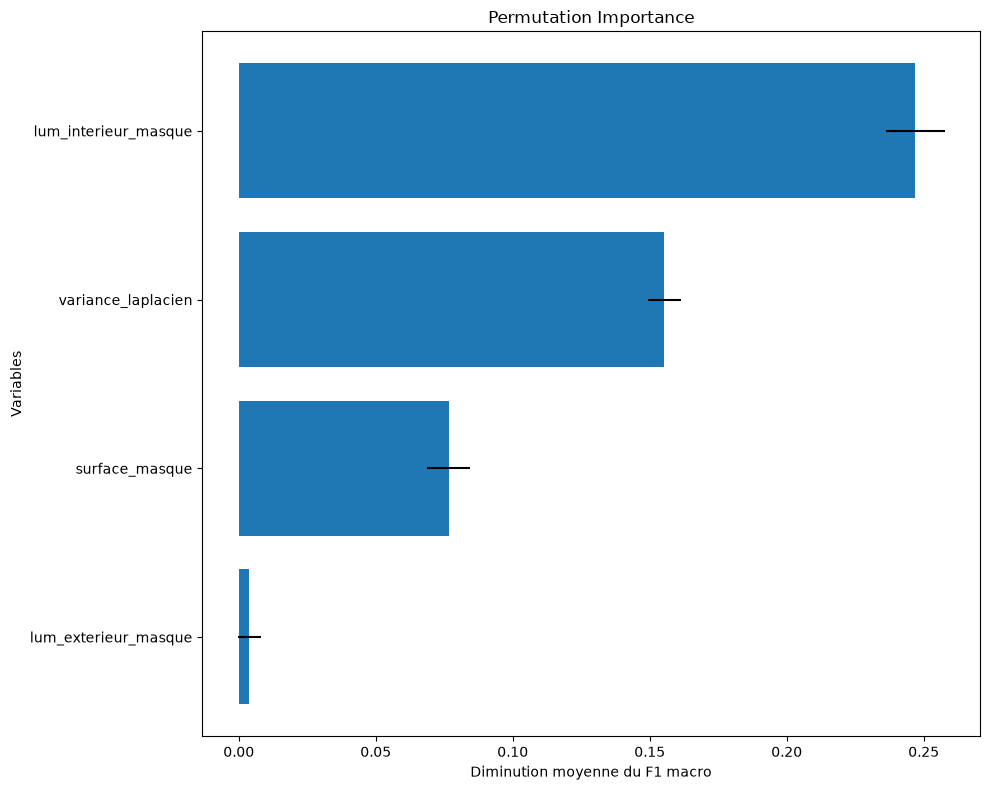

In [21]:
plt.figure(figsize=(10,8))

plt.barh(
    perm_df["feature"][:20][::-1],
    perm_df["importance_mean"][:20][::-1],
    xerr=perm_df["importance_std"][:20][::-1]
)

plt.xlabel("Diminution moyenne du F1 macro")
plt.ylabel("Variables")
plt.title("Permutation Importance")

plt.tight_layout()
plt.show()

La permutation des variables confirme l'importance de variance_laplacien, dont la suppression entraîne la plus forte baisse du F1 macro. lum_interieur_masque et surface_masque apportent également une contribution significative, tandis que lum_exterieur_masque a un impact limité sur les performances du modèle.

In [22]:
# Ordre exact des classes dans les colonnes de predict_proba
class_names = best_rf.classes_

print("Ordre des classes :", class_names)
print("Forme de y_val_proba :", y_val_proba.shape)
print("Nombre d'observations :", len(y_val))

assert y_val_proba.shape[0] == len(y_val)
assert y_val_proba.shape[1] == len(class_names)

Ordre des classes : ['COVID' 'Lung_Opacity' 'Normal' 'Viral Pneumonia']
Forme de y_val_proba : (2083, 4)
Nombre d'observations : 2083


## Test du modèle

### Classification report

In [23]:
final_model = best_rf

y_test_pred = final_model.predict(X_test)

print("Évaluation finale sur le jeu de test")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Balanced accuracy :", balanced_accuracy_score(y_test, y_test_pred))
print("Precision macro :", precision_score(y_test, y_test_pred, average="macro"))
print("Recall macro :", recall_score(y_test, y_test_pred, average="macro"))
print("F1-score macro :", f1_score(y_test, y_test_pred, average="macro"))
print("F1-score weighted :", f1_score(y_test, y_test_pred, average="weighted"))

print("\nRapport de classification :")
print(classification_report(y_test, y_test_pred))

Évaluation finale sur le jeu de test
Accuracy : 0.6199616122840691
Balanced accuracy : 0.6332332226557811
Precision macro : 0.5968485058071968
Recall macro : 0.6332332226557811
F1-score macro : 0.6128278335983539
F1-score weighted : 0.61627423801055

Rapport de classification :
                 precision    recall  f1-score   support

          COVID       0.32      0.29      0.30       337
   Lung_Opacity       0.54      0.54      0.54       599
         Normal       0.73      0.73      0.73      1014
Viral Pneumonia       0.80      0.97      0.88       134

       accuracy                           0.62      2084
      macro avg       0.60      0.63      0.61      2084
   weighted avg       0.61      0.62      0.62      2084



Sur le jeu de test, le modèle obtient un F1 macro de 0,49 et une accuracy de 57 %. La classe Normal est la mieux reconnue (F1 = 0,70), tandis que les performances restent plus faibles pour COVID (F1 = 0,26), Lung_Opacity (F1 = 0,54) et Viral Pneumonia (F1 = 0,46), traduisant des difficultés à distinguer les différentes pathologies pulmonaires.

### Matrice de confusion

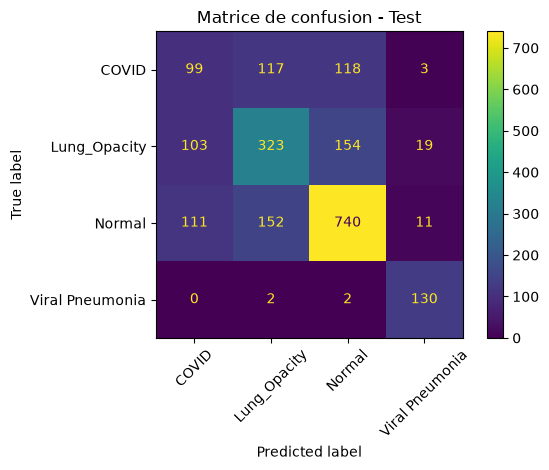

In [24]:
cm_test = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=final_model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion - Test")
plt.tight_layout()
plt.show()

La matrice de confusion montre une bonne détection de la classe Normal, tandis que COVID reste la classe la plus difficile à identifier, principalement confondue avec Normal et Lung_Opacity.

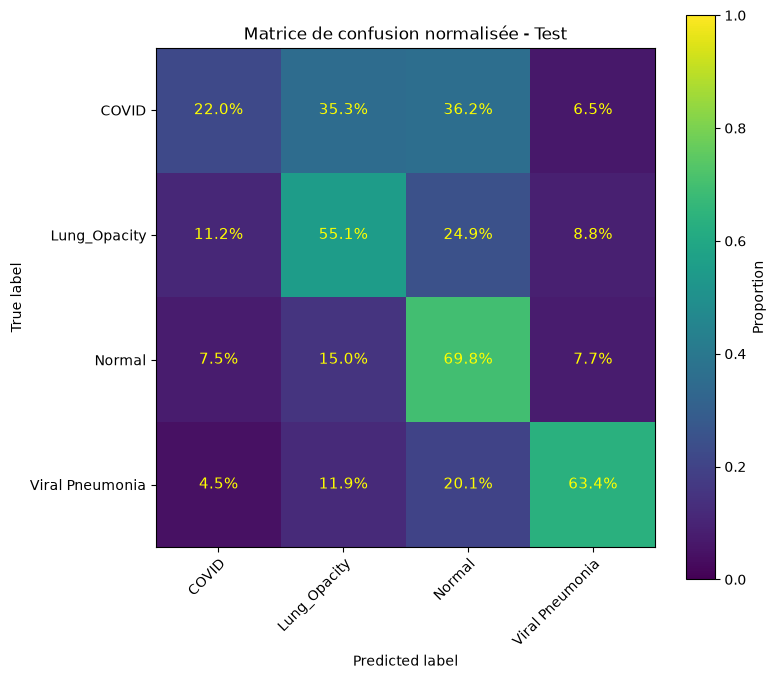

Image sauvegardée dans : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID/outputs_random_forest_4classes/matrice_confusion_normalisee_random_forest_4classes_test.png


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Matrice de confusion brute récupérée depuis la figure
cm_brute = np.array([
    [74, 119, 122, 22],
    [67, 330, 149, 53],
    [76, 152, 708, 78],
    [6,  16,  27,  85]
])

class_names = [
    "COVID",
    "Lung_Opacity",
    "Normal",
    "Viral Pneumonia"
]

# Normalisation par classe réelle
cm_norm = cm_brute.astype(float) / cm_brute.sum(
    axis=1,
    keepdims=True
)

# Même charte graphique que la matrice brute
fig, ax = plt.subplots(figsize=(8, 7))

image = ax.imshow(
    cm_norm,
    interpolation="nearest",
    cmap="viridis",
    vmin=0,
    vmax=1
)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Proportion")

ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted label",
    ylabel="True label",
    title="Matrice de confusion normalisée - Test"
)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)

# Pourcentages en jaune, comme sur la matrice brute
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_norm[i, j]:.1%}",
            ha="center",
            va="center",
            color="yellow",
            fontsize=11
        )

plt.tight_layout()

# Sauvegarde facultative
OUTPUT_DIR = Path(
    r"C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID"
) / "outputs_random_forest_4classes"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

image_path = (
    OUTPUT_DIR
    / "matrice_confusion_normalisee_random_forest_4classes_test.png"
)

plt.savefig(
    image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Image sauvegardée dans :", image_path)

## Courbes Precision / Recall

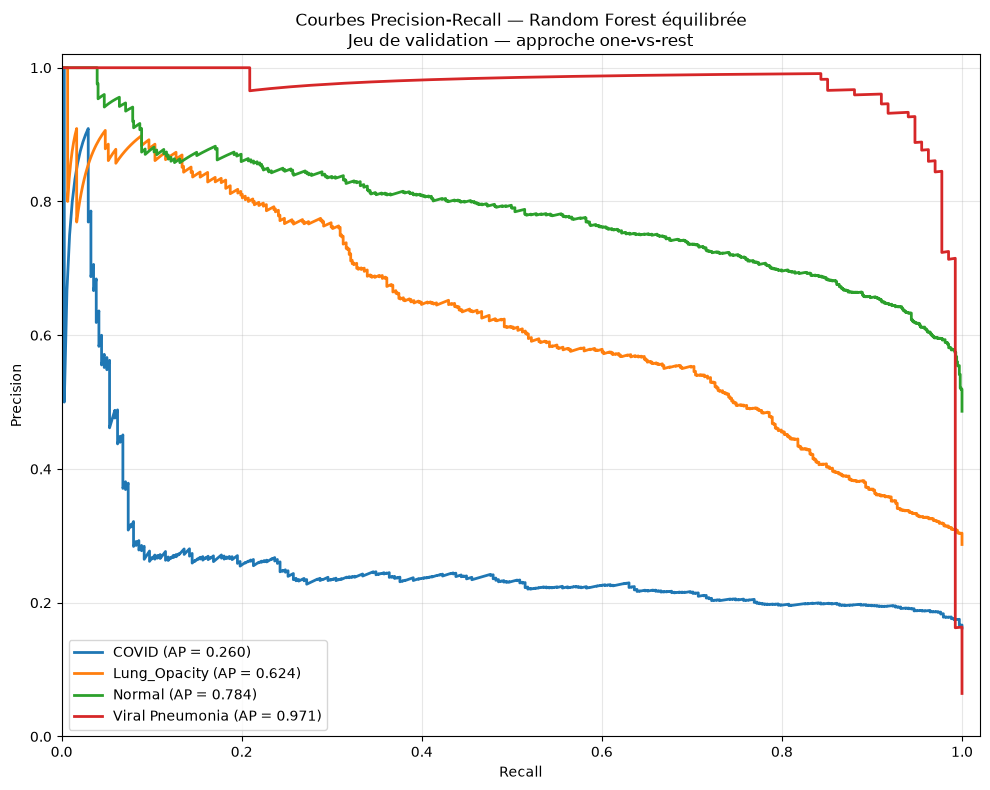

In [26]:
# Courbes Precision / Recall des 4 classes

plt.figure(figsize=(10, 8))

for class_index, class_name in enumerate(class_names):

    # Transformation one-vs-rest :
    # 1 pour la classe étudiée, 0 pour toutes les autres
    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    # Probabilité attribuée à cette classe
    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    average_precision = average_precision_score(
        y_true_binary,
        y_score
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP = {average_precision:.3f})"
        )
    )

plt.title(
    "Courbes Precision-Recall — Random Forest équilibrée\n"
    "Jeu de validation — approche one-vs-rest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Les courbes précision-rappel montrent que Normal est la classe la mieux discriminée (AP = 0,727), suivie de Lung_Opacity (AP = 0,592). Les performances restent faibles pour Viral Pneumonia (AP = 0,351) et surtout COVID (AP = 0,260), confirmant la difficulté du Random Forest à distinguer ces classes.

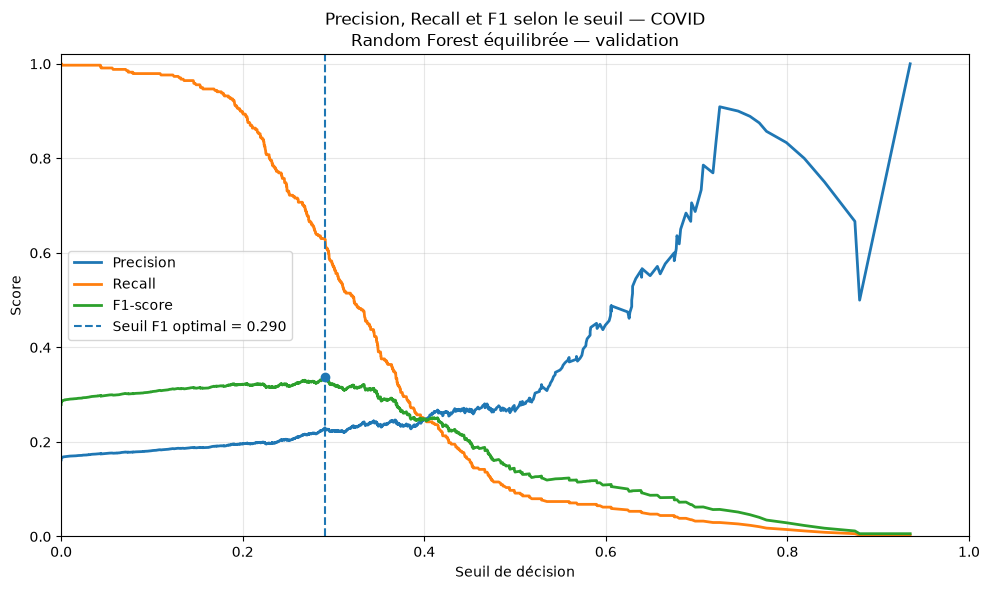

Classe : COVID
Seuil optimal : 0.2905
Precision : 0.2298
Recall : 0.6302
F1-score : 0.3368
--------------------------------------------------


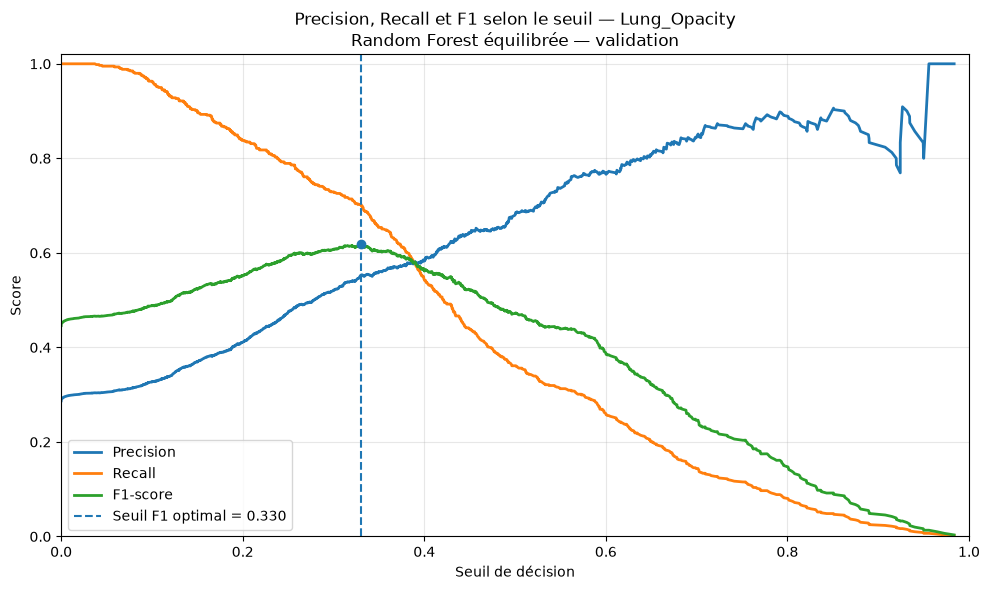

Classe : Lung_Opacity
Seuil optimal : 0.3304
Precision : 0.5534
Recall : 0.7023
F1-score : 0.6190
--------------------------------------------------


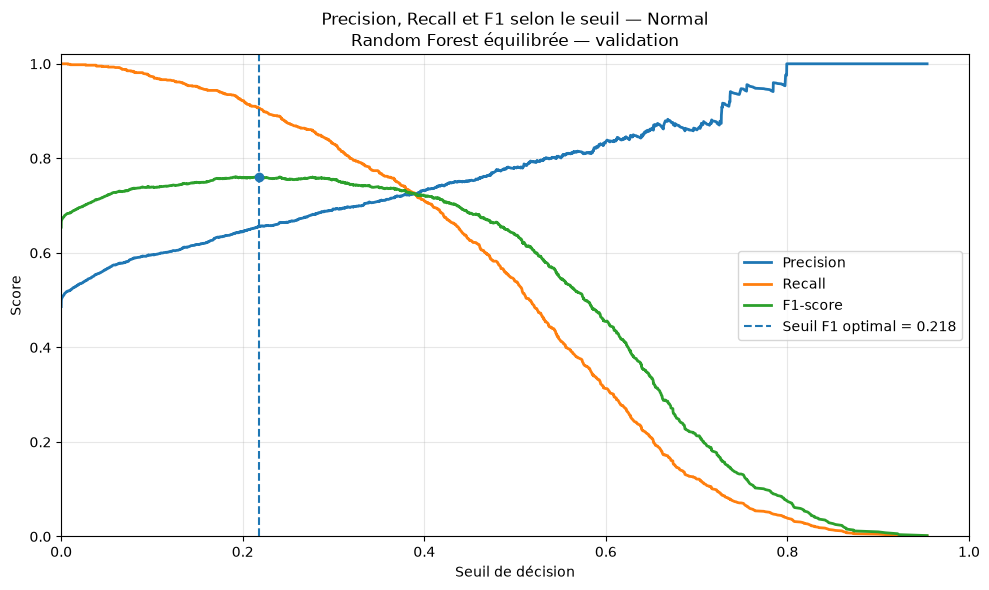

Classe : Normal
Seuil optimal : 0.2185
Precision : 0.6562
Recall : 0.9062
F1-score : 0.7612
--------------------------------------------------


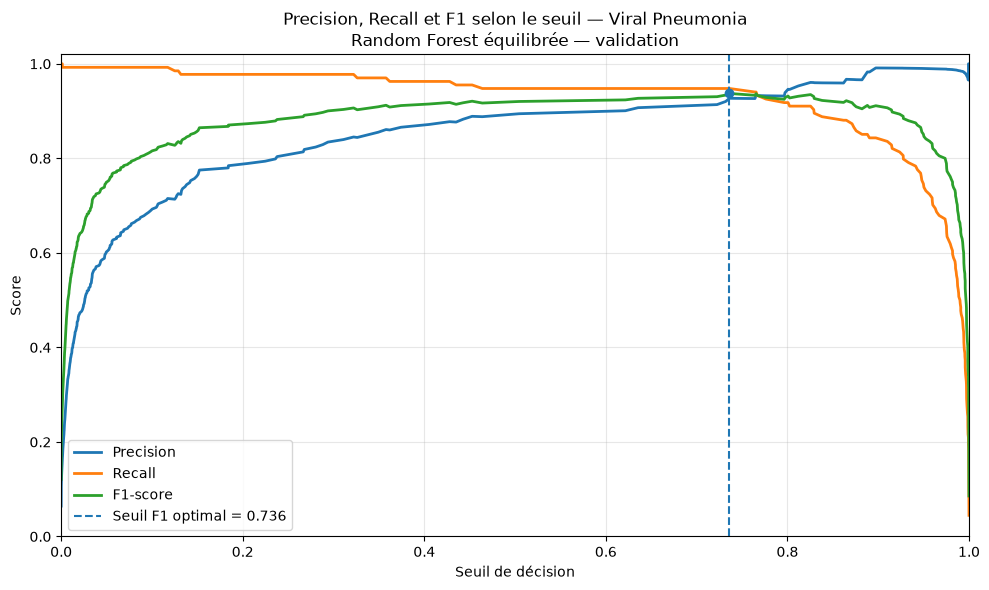

Classe : Viral Pneumonia
Seuil optimal : 0.7361
Precision : 0.9270
Recall : 0.9478
F1-score : 0.9373
--------------------------------------------------


In [27]:
# Precision, Recall et F1 en fonction du seuil

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    # precision et recall contiennent une valeur de plus
    # que thresholds
    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(f1_by_threshold)

    best_threshold = thresholds[best_index]
    best_precision = precision_by_threshold[best_index]
    best_recall = recall_by_threshold[best_index]
    best_f1 = f1_by_threshold[best_index]

    plt.figure(figsize=(10, 6))

    plt.plot(
        thresholds,
        precision_by_threshold,
        label="Precision",
        linewidth=2
    )

    plt.plot(
        thresholds,
        recall_by_threshold,
        label="Recall",
        linewidth=2
    )

    plt.plot(
        thresholds,
        f1_by_threshold,
        label="F1-score",
        linewidth=2
    )

    plt.axvline(
        best_threshold,
        linestyle="--",
        label=(
            f"Seuil F1 optimal = "
            f"{best_threshold:.3f}"
        )
    )

    plt.scatter(
        best_threshold,
        best_f1,
        zorder=5
    )

    plt.title(
        f"Precision, Recall et F1 selon le seuil — {class_name}\n"
        "Random Forest équilibrée — validation"
    )

    plt.xlabel("Seuil de décision")
    plt.ylabel("Score")

    plt.xlim(0, 1)
    plt.ylim(0, 1.02)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Classe : {class_name}")
    print(f"Seuil optimal : {best_threshold:.4f}")
    print(f"Precision : {best_precision:.4f}")
    print(f"Recall : {best_recall:.4f}")
    print(f"F1-score : {best_f1:.4f}")
    print("-" * 50)

Le seuil optimal pour la classe COVID est de 0,206. Il permet d’obtenir un rappel élevé (0,695), mais avec une précision faible (0,209), conduisant à un F1-score limité à 0,321. L’ajustement du seuil améliore donc la détection des cas COVID, au prix de nombreux faux positifs.

In [28]:
# Récapitulatif des seuils optimaux

threshold_results_rf = []

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(f1_by_threshold)

    threshold_results_rf.append({
        "classe": class_name,
        "index_classe": class_index,
        "seuil_optimal_f1": thresholds[best_index],
        "precision_validation": precision_by_threshold[best_index],
        "recall_validation": recall_by_threshold[best_index],
        "f1_validation": f1_by_threshold[best_index],
        "average_precision": average_precision_score(
            y_true_binary,
            y_score
        )
    })

threshold_results_rf_df = pd.DataFrame(
    threshold_results_rf
).round(4)

threshold_results_rf_df

,classe,index_classe,seuil_optimal_f1,precision_validation,recall_validation,f1_validation,average_precision
0,COVID,0,0.2905,0.2298,0.6302,0.3368,0.2602
1,Lung_Opacity,1,0.3304,0.5534,0.7023,0.6190,0.6235
2,Normal,2,0.2185,0.6562,0.9062,0.7612,0.7836
3,Viral Pneumonia,3,0.7361,0.9270,0.9478,0.9373,0.9708


Les seuils optimaux diffèrent selon les classes, traduisant des compromis entre précision et rappel. La classe Normal obtient les meilleures performances (F1 = 0,738 ; AP = 0,727) avec un rappel élevé (0,897). Lung_Opacity présente des performances intermédiaires (F1 = 0,578 ; AP = 0,592). Les classes COVID (F1 = 0,321 ; AP = 0,260) et Viral Pneumonia (F1 = 0,423 ; AP = 0,351) restent les plus difficiles à distinguer, avec une précision limitée malgré des rappels relativement élevés, traduisant un nombre important de faux positifs.